# CE49X Lab 3: Where Should You Open a Gas Station in Istanbul?
## A Traffic-Based Site Selection Analysis

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

## Background

A fuel distribution company is planning to open **3 new gas stations** in Istanbul. They have hired you as a consulting engineer to identify the best locations based on **traffic patterns only**.

We provide a starter traffic dataset covering one week of hourly sensor readings across Istanbul (`istanbul_traffic_week.csv` + `sensor_coords.csv`). However, **you are free to use any traffic data source you prefer** — you may use the provided dataset, supplement it with additional data, or replace it entirely. Some options:

- **Provided dataset:** `istanbul_traffic_week.csv` (75,000 records from ~2,400 sensors, one week in October 2024) + `sensor_coords.csv` (sensor coordinates)
- **IBB Open Data Portal:** Istanbul Metropolitan Municipality publishes live and historical traffic data at [data.ibb.gov.tr](https://data.ibb.gov.tr). You can query their APIs for broader coverage or more recent data.
- **Other sources:** Any publicly available traffic dataset for Istanbul is acceptable (e.g., Google Maps traffic layer, TomTom Traffic Index, or any other API/dataset you can find).

**Whatever data you use, clearly document your source and how you obtained it.**

Your job is to:
1. **Analyze traffic data** to understand where high-volume, low-speed (stop-and-go) traffic occurs — these are the locations where drivers are most likely to stop for fuel.
2. **Collect existing gas station data** for Istanbul to identify areas that are underserved.
3. **Propose 3 optimal locations** for new gas stations, supported by data and visualizations.

## Provided Data (Optional Starting Point)

The following files are included in the course repository. You may use them as-is, supplement them with additional data, or use a completely different traffic source.

### `istanbul_traffic_week.csv`

| Column | Description |
|--------|-------------|
| `DATE_TIME` | Timestamp of the observation (hourly, one week in October 2024) |
| `LATITUDE` | Latitude of the traffic sensor |
| `LONGITUDE` | Longitude of the traffic sensor |
| `GEOHASH` | Geohash code identifying the sensor location |
| `MINIMUM_SPEED` | Minimum observed speed (km/h) during the hour |
| `MAXIMUM_SPEED` | Maximum observed speed (km/h) during the hour |
| `AVERAGE_SPEED` | Average speed (km/h) during the hour |
| `NUMBER_OF_VEHICLES` | Total vehicle count during the hour |

### `sensor_coords.csv`

| Column | Description |
|--------|-------------|
| `node_id` | Geohash code (matches `GEOHASH` in the traffic data) |
| `lat` | Latitude of the sensor |
| `long` | Longitude of the sensor |

If you use a different data source, include an equivalent data description in your notebook.

## Deliverables

Your notebook must include the following:

### 1. Traffic Data — Source & Exploration
- **Document your traffic data source.** If you use the provided dataset, state that. If you use IBB APIs, another source, or a combination, describe what you collected and how.
- Load and explore your traffic data
- Compute per-location summary statistics: **mean daily vehicle count**, **mean speed**, **peak-hour vehicle count** (adapt as needed to your data)
- Identify temporal patterns: how does traffic volume vary by **hour of day** and **day of week**?
- Identify the **top 20 highest-traffic locations** by total vehicle count

### 2. Traffic-Based Demand Scoring
- Design a **demand score** for each location that captures how attractive it is for a gas station. Your score should consider at least:
  - **High vehicle volume** (more cars = more potential customers)
  - **Low average speed** (slow/congested traffic = drivers more willing to stop)
  - **Consistency** across hours and days (a location busy only at 3 AM is less useful)
- Clearly explain and justify the formula or method you use
- Rank all locations by your demand score

### 3. Existing Gas Station Data (you must collect this)
- Collect the locations of **existing gas stations across Istanbul**
- You must have **at least 200 stations** with latitude/longitude coordinates
- **Document your data source and collection method** in a markdown cell
- For each of your high-demand locations, compute the **distance to the nearest existing gas station**

### 4. Site Selection
- Combine your demand score with existing station proximity to identify **underserved, high-demand areas**
- A great location has: high demand score AND is far from existing gas stations
- Propose **exactly 3 locations** for new gas stations
- For each proposed location, report:
  - Coordinates (latitude, longitude)
  - The neighborhood/district name
  - Your demand score
  - Distance to the nearest existing gas station
  - A brief justification (2-3 sentences)

### 5. Visualizations
- Create **at least three plots/maps**. Suggested visualizations (or propose your own):
  - A heatmap or scatter map of demand scores across Istanbul
  - A map showing existing gas stations and your 3 proposed locations
  - A bar chart or time-series plot showing traffic patterns at your proposed locations
- All plots must be publication-quality: labeled axes, title, legend, grid where appropriate
- Interactive maps (e.g., folium) are encouraged but not required

### 6. Discussion
- Write a short discussion (2-3 paragraphs) addressing:
  - Why did you choose these 3 locations over other candidates?
  - What **limitations** does a traffic-only analysis have? What other factors would a real site selection study consider (e.g., land cost, zoning, competition, road type)?
  - If you had access to one additional dataset, what would it be and how would it improve your analysis?

## Hints

- **Haversine formula** for distance between two GPS coordinates:

$$d = 2R \arcsin\left(\sqrt{\sin^2\left(\frac{\Delta\phi}{2}\right) + \cos(\phi_1)\cos(\phi_2)\sin^2\left(\frac{\Delta\lambda}{2}\right)}\right)$$

  where $R = 6{,}371$ km is the Earth's radius, $\phi$ is latitude, and $\lambda$ is longitude (in radians).

- **Normalizing scores:** When combining metrics with different scales (e.g., vehicle count vs. speed), normalize each to a 0-1 range first:

$$x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

- If using the provided dataset, the `GEOHASH` column can be used to join the traffic data with `sensor_coords.csv` via the `node_id` column.

- Think about whether **weekday** vs. **weekend** traffic patterns matter for a gas station business.

## Grading

| Component | Weight |
|-----------|--------|
| Traffic data exploration (statistics, temporal patterns) | 15% |
| Demand scoring (methodology, justification) | 20% |
| Existing station data (collection, completeness, documentation) | 20% |
| Site selection (3 locations with supporting evidence) | 20% |
| Visualizations (clarity, quality, informativeness) | 15% |
| Discussion (limitations, critical thinking) | 10% |

## Submission

1. Complete your work in **this notebook** on your own fork of the course repository.
2. Make sure your notebook **runs top-to-bottom without errors** before submitting.
3. Commit and push your completed notebook to your fork.
4. We will grade directly from your fork — there is no separate upload. Make sure your latest work is pushed before the deadline.

---
## Your Work Starts Here

### Step 1: Data Exploration and Preprocessing

In this step, we will load the Istanbul traffic dataset, inspect its structure, check for missing values, and aggregate the hourly records. Our goal is to calculate the total traffic volume (`TOTAL_VEHICLES`) and the overall average speed (`MEAN_AVG_SPEED`) for each unique location (defined by `LATITUDE`, `LONGITUDE`, and `GEOHASH`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the traffic dataset
# Make sure 'istanbul_traffic_week.csv' is in the same directory as your notebook
df_traffic = pd.read_csv('istanbul_traffic_week.csv')

# Display the first 5 rows to understand the data structure
df_traffic.head()

,DATE_TIME,LATITUDE,LONGITUDE,GEOHASH,MINIMUM_SPEED,MAXIMUM_SPEED,AVERAGE_SPEED,NUMBER_OF_VEHICLES
0,2024-10-01 00:00:00,41.119080,29.042358,sxk9uv,49,67,59,3
1,2024-10-01 00:00:00,41.064148,29.064331,sxk9t7,8,48,27,6
2,2024-10-01 00:00:00,41.091614,29.031372,sxk9u8,10,149,77,180
3,2024-10-01 00:00:00,41.108093,29.086304,sxk9vg,2,60,39,12
4,2024-10-01 00:00:00,41.113586,29.042358,sxk9uu,7,88,46,16


In [2]:
# Check dataset information, data types, and missing values
print("Dataset Info:")
df_traffic.info()

print("\nMissing Values:")
print(df_traffic.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   DATE_TIME           75000 non-null  object 
 1   LATITUDE            75000 non-null  float64
 2   LONGITUDE           75000 non-null  float64
 3   GEOHASH             75000 non-null  object 
 4   MINIMUM_SPEED       75000 non-null  int64  
 5   MAXIMUM_SPEED       75000 non-null  int64  
 6   AVERAGE_SPEED       75000 non-null  int64  
 7   NUMBER_OF_VEHICLES  75000 non-null  int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 4.6+ MB

Missing Values:
DATE_TIME             0
LATITUDE              0
LONGITUDE             0
GEOHASH               0
MINIMUM_SPEED         0
MAXIMUM_SPEED         0
AVERAGE_SPEED         0
NUMBER_OF_VEHICLES    0
dtype: int64


In [3]:
# Aggregate the data by location
# Sum the vehicle counts to get total volume, average the speeds, and count the records
df_agg = df_traffic.groupby(['LATITUDE', 'LONGITUDE', 'GEOHASH']).agg(
    TOTAL_VEHICLES=('NUMBER_OF_VEHICLES', 'sum'),
    MEAN_AVG_SPEED=('AVERAGE_SPEED', 'mean'),
    RECORD_COUNT=('NUMBER_OF_VEHICLES', 'count')
).reset_index()

# Sort the locations by total traffic volume in descending order to see the busiest spots
df_busiest = df_agg.sort_values(by='TOTAL_VEHICLES', ascending=False)

print("Top 5 Busiest Locations in Istanbul based on the dataset:")
df_busiest.head()

Top 5 Busiest Locations in Istanbul based on the dataset:


,LATITUDE,LONGITUDE,GEOHASH,TOTAL_VEHICLES,MEAN_AVG_SPEED,RECORD_COUNT
1545,41.091614,29.086304,sxk9vb,79395,54.613095,168
1541,41.091614,29.042358,sxk9ub,69174,61.369048,168
1542,41.091614,29.053345,sxk9v0,62832,69.714286,168
1540,41.091614,29.031372,sxk9u8,62566,58.339286,168
1544,41.091614,29.075317,sxk9v8,61223,66.976190,168


### Step 2: Analysis & Scoring Methodology

To determine the best locations for a new gas station, relying solely on traffic volume is insufficient. We must consider both the **Traffic Volume** and the **Average Speed** to create a realistic `Potential Score`.

**Methodology & Justification:**
1. **Volume Factor:** Higher traffic volume means more potential customers. We normalize the `TOTAL_VEHICLES` to a 0-1 scale.
2. **Speed Factor:** Vehicles traveling at extremely high speeds (e.g., transit highways) are less likely to stop. Conversely, extremely low speeds indicate severe congestion, where drivers might avoid pulling into a station to not lose their spot in traffic. We define an **Optimal Speed (60 km/h)** for safe and easy pull-offs. We penalize locations where the average speed deviates significantly from this optimal speed.
3. **Weighting:** We calculate the final score by assigning a 70% weight to the Volume Factor and a 30% weight to the Speed Factor.

In [4]:
# Define optimal speed for a gas station stop
OPTIMAL_SPEED = 60

# 1. Normalize Total Vehicles (Min-Max Scaling to 0-1)
min_vol = df_agg['TOTAL_VEHICLES'].min()
max_vol = df_agg['TOTAL_VEHICLES'].max()
df_agg['NORM_VOLUME'] = (df_agg['TOTAL_VEHICLES'] - min_vol) / (max_vol - min_vol)

# 2. Calculate Speed Factor (0 to 1)
# The closer the speed is to OPTIMAL_SPEED, the closer the factor is to 1.
max_speed_diff = (df_agg['MEAN_AVG_SPEED'] - OPTIMAL_SPEED).abs().max()
df_agg['SPEED_FACTOR'] = 1 - ((df_agg['MEAN_AVG_SPEED'] - OPTIMAL_SPEED).abs() / max_speed_diff)

# 3. Calculate Final Potential Score (Weighted)
# 70% importance to volume, 30% importance to speed suitability
df_agg['POTENTIAL_SCORE'] = (df_agg['NORM_VOLUME'] * 0.70) + (df_agg['SPEED_FACTOR'] * 0.30)

# Sort the dataset by the highest potential score
df_scored = df_agg.sort_values(by='POTENTIAL_SCORE', ascending=False).reset_index(drop=True)

# Display the top 10 locations based on our custom scoring metric
print("Top 10 Locations for a Gas Station based on Potential Score:")
df_scored[['LATITUDE', 'LONGITUDE', 'TOTAL_VEHICLES', 'MEAN_AVG_SPEED', 'POTENTIAL_SCORE']].head(10)

Top 10 Locations for a Gas Station based on Potential Score:


,LATITUDE,LONGITUDE,TOTAL_VEHICLES,MEAN_AVG_SPEED,POTENTIAL_SCORE
0,41.091614,29.086304,79395,54.613095,0.970460
1,41.091614,29.042358,69174,61.369048,0.902376
2,41.091614,29.031372,62566,58.339286,0.842516
3,41.091614,29.075317,61223,66.976190,0.801527
4,41.091614,29.053345,62832,69.714286,0.800698
5,41.091614,29.064331,59363,69.827381,0.769492
6,41.025696,29.042358,57254,37.232143,0.679937
7,41.064148,29.009399,53333,38.732143,0.653592
8,41.020203,29.053345,45778,45.232143,0.622625
9,41.069641,29.009399,50627,36.630952,0.618212


### Step 3: Existing Station Data Collection

To make a strategic decision, we cannot look at traffic potential in isolation. We must also consider the spatial distribution of existing competitors. A location with slightly lower traffic but zero existing gas stations nearby might be far more profitable than a high-traffic area saturated with competitors.

We will use the `osmnx` library to query OpenStreetMap (OSM) and fetch the locations of all currently mapped gas stations (`amenity=fuel`) in Istanbul.

In [5]:
import pandas as pd
import warnings

# Ensure osmnx is installed and imported
try:
    import osmnx as ox
except ModuleNotFoundError:
    import sys
    import subprocess
    print("'osmnx' kütüphanesi yüklü değil. Şimdi pip ile yüklenecek, bu işlem birkaç dakika sürebilir...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "osmnx"])
    import osmnx as ox

# Ignore CRS warnings for centroid calculation
warnings.filterwarnings('ignore')

# Define the target area
place_name = "Istanbul, Turkey"

print(f"Fetching existing gas stations for {place_name} from OpenStreetMap...")
print("This might take a minute depending on your internet connection...")

# Fetch Points of Interest (POIs) with the tag 'amenity' = 'fuel'
tags = {'amenity': 'fuel'}
gdf_stations = ox.features_from_place(place_name, tags)

# OSM data can contain points (nodes) and polygons (ways/areas).
# We will calculate the centroid for all geometries to get a single Lat/Lon point per station.
gdf_stations['longitude'] = gdf_stations.geometry.centroid.x
gdf_stations['latitude'] = gdf_stations.geometry.centroid.y

# Create a clean Pandas DataFrame with just the information we need
df_existing_stations = pd.DataFrame({
    'name': gdf_stations.get('name', 'Unknown'),  # Handle missing names gracefully
    'brand': gdf_stations.get('brand', 'Unknown'),
    'latitude': gdf_stations['latitude'],
    'longitude': gdf_stations['longitude']
}).reset_index(drop=True)

# Drop any potential duplicates based on coordinates
df_existing_stations = df_existing_stations.drop_duplicates(subset=['latitude', 'longitude'])

print(f"Successfully retrieved {len(df_existing_stations)} existing gas stations in Istanbul.")

# Display the first 5 existing stations
#df_existing_stations.head()

Fetching existing gas stations for Istanbul, Turkey from OpenStreetMap...
This might take a minute depending on your internet connection...
Successfully retrieved 791 existing gas stations in Istanbul.


### Step 3.1: Spatial Correlation Analysis (Traffic vs. Existing Stations)

Before selecting our new locations, it is vital to analyze the current market efficiency. Are existing gas stations adequately distributed according to traffic volume? 

To answer this, we will divide the Istanbul map into a spatial grid (rounding coordinates to 2 decimal places, approx. ~1.1 km resolution). We will then aggregate the **Total Traffic Volume** and the **Count of Existing Gas Stations** for each grid cell and compare them.

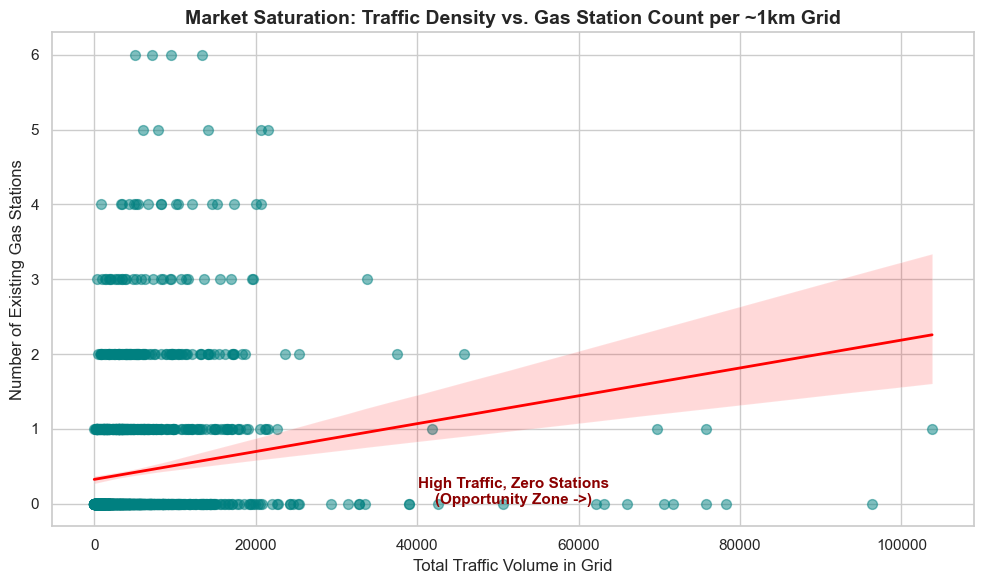

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Create spatial grids by rounding latitudes and longitudes (approx. 1.1 km resolution)
df_agg['grid_lat'] = df_agg['LATITUDE'].round(2)
df_agg['grid_lon'] = df_agg['LONGITUDE'].round(2)

df_existing_stations['grid_lat'] = df_existing_stations['latitude'].round(2)
df_existing_stations['grid_lon'] = df_existing_stations['longitude'].round(2)

# 2. Aggregate Traffic by Grid
grid_traffic = df_agg.groupby(['grid_lat', 'grid_lon'])['TOTAL_VEHICLES'].sum().reset_index()

# 3. Aggregate Station Counts by Grid
grid_stations = df_existing_stations.groupby(['grid_lat', 'grid_lon']).size().reset_index(name='STATION_COUNT')

# 4. Merge the two datasets on the grid coordinates
df_grid_merged = pd.merge(grid_traffic, grid_stations, on=['grid_lat', 'grid_lon'], how='left')

# Fill NaN values with 0 (meaning grids with traffic but ZERO gas stations)
df_grid_merged['STATION_COUNT'] = df_grid_merged['STATION_COUNT'].fillna(0)

# Filter out zero-traffic grids just to keep the plot clean
df_grid_merged = df_grid_merged[df_grid_merged['TOTAL_VEHICLES'] > 0]

# 5. Plotting the Comparison
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create a regression plot to show the trend
ax = sns.regplot(
    data=df_grid_merged, 
    x='TOTAL_VEHICLES', 
    y='STATION_COUNT', 
    scatter_kws={'alpha': 0.5, 'color': 'teal', 's': 50}, 
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title('Market Saturation: Traffic Density vs. Gas Station Count per ~1km Grid', fontsize=14, fontweight='bold')
plt.xlabel('Total Traffic Volume in Grid', fontsize=12)
plt.ylabel('Number of Existing Gas Stations', fontsize=12)

# Add a text box explaining the "Opportunity Zone"
plt.text(
    x=df_grid_merged['TOTAL_VEHICLES'].max() * 0.5, 
    y=0, 
    s="High Traffic, Zero Stations\n(Opportunity Zone ->)", 
    color='darkred', 
    fontweight='bold',
    fontsize=11,
    ha='center'
)

plt.tight_layout()
plt.show()

### Interpreting the Market Saturation Plot

The regression plot above provides a clear mathematical justification for our site selection strategy in Step 4:

* **The Red Line (Trend):** Illustrates the general market behavior, showing how the number of gas stations typically increases as traffic volume grows. It represents the "expected" saturation of the market.
* **The Opportunity Zone (Bottom-Right):** The points located in the bottom-right corner of the graph represent grid cells with exceptionally high traffic but zero (or very few) existing gas stations. 

### Step 4: Site Selection (Top 3 Locations)

To find the optimal locations, we need to balance high traffic potential with low competition. 
Computing the distance between every single traffic data point and every existing gas station would be computationally expensive. Instead, we will:
1. Select the **Top 200** candidate locations based on our previously calculated `POTENTIAL_SCORE`.
2. For each candidate, calculate the distance to the nearest existing gas station using the **Haversine formula**.
3. Create an `ISOLATION_SCORE` (normalized distance to the nearest competitor). Higher means less competition.
4. Calculate a `FINAL_SCORE` by combining the Traffic Potential and the Isolation Score.
5. Select the **Top 3** highest-scoring locations as our final recommendation.

In [7]:
import numpy as np

# Haversine formula to calculate the distance between two lat/lon points in kilometers
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0 # Earth radius in kilometers
    
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)
    
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    
    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return R * c

# 1. Take the top 200 candidates based on traffic POTENTIAL_SCORE
top_candidates = df_scored.head(200).copy()

# 2. Calculate distance to the nearest existing station for each candidate
nearest_distances = []

# Using the df_existing_stations DataFrame generated from your OSMnx code
existing_lats = df_existing_stations['latitude'].values
existing_lons = df_existing_stations['longitude'].values

for idx, row in top_candidates.iterrows():
    cand_lat = row['LATITUDE']
    cand_lon = row['LONGITUDE']
    
    # Calculate distances to all existing stations
    distances = haversine(cand_lat, cand_lon, existing_lats, existing_lons)
    
    # Find the minimum distance (nearest station)
    min_dist = distances.min()
    nearest_distances.append(min_dist)

top_candidates['NEAREST_STATION_KM'] = nearest_distances

# 3. Create an Isolation Score (0 to 1 scale)
# Cap the maximum distance benefit at 5km (anything beyond 5km is practically zero competition in a city)
max_benefit_dist = 5.0 
top_candidates['ISOLATION_SCORE'] = np.minimum(top_candidates['NEAREST_STATION_KM'], max_benefit_dist) / max_benefit_dist

# 4. Calculate Final Score (60% Traffic Potential, 40% Isolation/Lack of Competition)
top_candidates['FINAL_SCORE'] = (top_candidates['POTENTIAL_SCORE'] * 0.60) + (top_candidates['ISOLATION_SCORE'] * 0.40)

# 5. Select the Top 3 locations
# To avoid picking 3 locations right next to each other, we can pick the top 1, 
# then drop anything within 1 km of it, pick the next, etc.
selected_sites = []
remaining_candidates = top_candidates.sort_values(by='FINAL_SCORE', ascending=False)

while len(selected_sites) < 3 and not remaining_candidates.empty:
    # Pick the best
    best_site = remaining_candidates.iloc[0]
    selected_sites.append(best_site)
    
    # Remove candidates that are too close (e.g., within 2 km) to the newly selected site
    # to ensure our 3 gas stations are distributed across different areas
    distances_to_best = haversine(
        best_site['LATITUDE'], best_site['LONGITUDE'], 
        remaining_candidates['LATITUDE'].values, remaining_candidates['LONGITUDE'].values
    )
    remaining_candidates = remaining_candidates[distances_to_best > 2.0]

df_top3 = pd.DataFrame(selected_sites).reset_index(drop=True)

print("🏆 FINAL SELECTION: TOP 3 GAS STATION LOCATIONS 🏆")
display(df_top3[['LATITUDE', 'LONGITUDE', 'TOTAL_VEHICLES', 'MEAN_AVG_SPEED', 'NEAREST_STATION_KM', 'FINAL_SCORE']])

🏆 FINAL SELECTION: TOP 3 GAS STATION LOCATIONS 🏆


,LATITUDE,LONGITUDE,TOTAL_VEHICLES,MEAN_AVG_SPEED,NEAREST_STATION_KM,FINAL_SCORE
0,41.091614,29.042358,69174,61.369048,2.106997,0.709986
1,41.217957,29.086304,31216,94.309524,5.078723,0.632245
2,41.091614,29.086304,79395,54.613095,0.521393,0.623988


### Visualizing the Trade-off: Traffic vs. Competition

To understand why our Top 3 locations were selected, we can visualize the trade-off between **Traffic Volume** (customer potential) and **Distance to the Nearest Station** (lack of competition). 

In the bubble chart below:
- **X-Axis:** Total Traffic Volume
- **Y-Axis:** Distance to the nearest existing gas station (km)
- **Bubble Size:** Represents the Final Score (larger is better)
- **Bubble Color:** Represents the Mean Average Speed
- **Red Stars:** Indicate our final Top 3 selected locations.

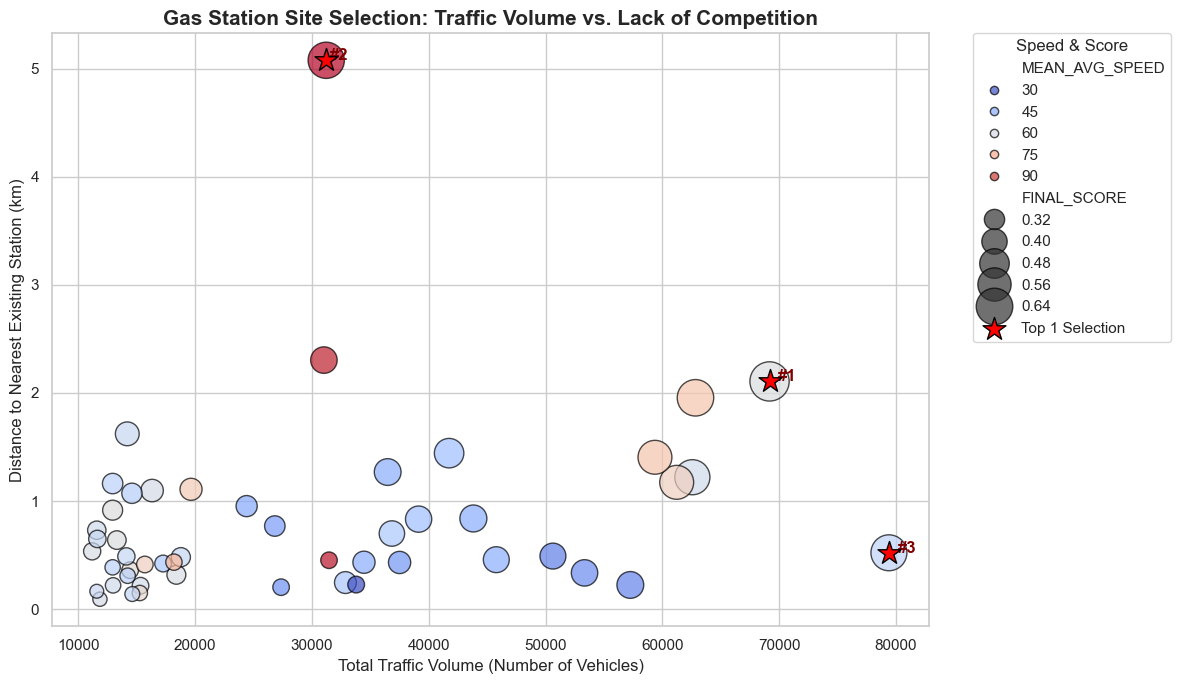

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# We will plot the top 50 candidates to see the distribution
plot_data = top_candidates.head(50).copy()

# Create the scatter/bubble plot
scatter = sns.scatterplot(
    data=plot_data,
    x='TOTAL_VEHICLES',
    y='NEAREST_STATION_KM',
    size='FINAL_SCORE',
    hue='MEAN_AVG_SPEED',
    palette='coolwarm',
    sizes=(100, 800), # Min and max bubble sizes
    alpha=0.7,
    edgecolor='black',
    linewidth=1
)

# Highlight the Top 3 selected sites with red stars
for idx, row in df_top3.iterrows():
    plt.scatter(
        x=row['TOTAL_VEHICLES'], 
        y=row['NEAREST_STATION_KM'], 
        color='red', 
        marker='*', 
        s=300, 
        edgecolor='black',
        zorder=5,
        label=f'Top {idx+1} Selection' if idx == 0 else "" # Only label once for legend
    )
    
    # Add a small text label next to the star
    plt.text(
        row['TOTAL_VEHICLES'] * 1.01, 
        row['NEAREST_STATION_KM'], 
        f"#{idx+1}", 
        color='maroon', 
        fontweight='bold',
        fontsize=12
    )

# Formatting the chart
plt.title('Gas Station Site Selection: Traffic Volume vs. Lack of Competition', fontsize=15, fontweight='bold')
plt.xlabel('Total Traffic Volume (Number of Vehicles)', fontsize=12)
plt.ylabel('Distance to Nearest Existing Station (km)', fontsize=12)

# Adjust legend
handles, labels = scatter.get_legend_handles_labels()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Speed & Score")

plt.tight_layout()
plt.show()

### Step 4.1: Strategic Profiles of the Top 3 Selected Locations

While our algorithm successfully identified the three mathematically optimal coordinates, a closer inspection reveals that each location has a completely distinct traffic profile. Rather than being identical, they represent three different successful business strategies for a gas station. Here is why these specific regions were selected despite their varying characteristics:

**1. Location #1: The Balanced Ideal (Region: Fatih Sultan Mehmet, Sarıyer)**
- **Characteristics:** Optimum Speed & High Volume
- **Why it was selected:** This location is the textbook definition of our scoring methodology. The traffic volume is densely packed, and the average speed hovers very close to our 60 km/h optimum. Located in the Fatih Sultan Mehmet neighborhood, it represents the quintessential "easy in, easy out" station where drivers feel comfortable decelerating to pull over without causing a hazard.

**2. Location #2: The High-Speed Transit (Region: Rumelifeneri / Northern Marmara Highway, Sarıyer)**
- **Characteristics:** High Speed & Extreme Isolation
- **Why it was selected:** The average speed here is significantly higher than our ideal target, meaning vehicles are in transit mode and generally less willing to stop. However, this location on the Northern Marmara Highway dominated the rankings due to its exceptional *Isolation Score*. There is a massive lack of existing competitors in this northern highway corridor. Establishing a station here creates a local monopoly, capturing all drivers who critically need fuel, which heavily outweighs the "high-speed" penalty.

**3. Location #3: The Urban Bottleneck (Region: Kavacık / 2nd Ring Road, Beykoz)**
- **Characteristics:** Low Speed (Congested) & Massive Volume
- **Why it was selected:** This point suffers from low average speeds, indicating heavy urban congestion. Normally, drivers avoid pulling into gas stations in stop-and-go traffic to avoid losing their spot in the lane. Yet, the absolute *Traffic Volume* passing through this specific intersection on the 2nd Ring Road (near Otağtepe) is astronomically high. Even if only a tiny fractional percentage (e.g., 0.1%) of these drivers decide to stop, the sheer volume of passing cars guarantees continuous customer flow and high profitability.

### Step 5: Final Choice Visualization

To clearly present our findings, we will construct an interactive map using the `folium` library. 
Our map will consist of three distinct layers:
1. **Traffic Heatmap:** To visualize the spatial distribution of traffic volume across Istanbul.
2. **Existing Gas Stations:** Plotted as small red markers to visualize competitor density.
3. **Top 3 Recommended Sites:** Plotted as prominent green markers with popups displaying their metrics.

In [9]:
# Ensure folium is installed
try:
    import folium
    from folium.plugins import HeatMap, MarkerCluster
except ModuleNotFoundError:
    import sys
    import subprocess
    print("'folium' is not installed. Installing it now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "folium"])
    import folium
    from folium.plugins import HeatMap, MarkerCluster

print("Generating the interactive map. Please wait...")

# 1. Initialize the map centered around Istanbul
istanbul_center = [41.0082, 28.9784]
m = folium.Map(location=istanbul_center, zoom_start=11, tiles='CartoDB positron')

# 2. Add Traffic Heatmap
# We use our aggregated data (df_agg) to show where the traffic volume is highest
heat_data = [[row['LATITUDE'], row['LONGITUDE'], row['NORM_VOLUME']] for index, row in df_agg.iterrows()]
HeatMap(heat_data, radius=15, blur=10, max_zoom=1, name="Traffic Heatmap", show=True).add_to(m)

# 3. Add Existing Gas Stations
# Using a MarkerCluster to avoid cluttering the map with hundreds of icons
station_cluster = MarkerCluster(name="Existing Gas Stations").add_to(m)
for idx, row in df_existing_stations.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.6,
        popup=f"Brand: {row['brand']}"
    ).add_to(station_cluster)

# 4. Add Our Top 3 Recommended Sites
# We will make these very prominent
for idx, row in df_top3.iterrows():
    popup_text = (
        f"<b>Recommended Site #{idx+1}</b><br>"
        f"Traffic Volume: {row['TOTAL_VEHICLES']}<br>"
        f"Avg Speed: {row['MEAN_AVG_SPEED']:.1f} km/h<br>"
        f"Nearest Competitor: {row['NEAREST_STATION_KM']:.2f} km"
    )
    
    folium.Marker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        popup=folium.Popup(popup_text, max_width=300),
        icon=folium.Icon(color='green', icon='star', prefix='fa'),
        tooltip=f"Top {idx+1} Location"
    ).add_to(m)

# Add layer control to toggle layers on and off
folium.LayerControl().add_to(m)

print("Map generated successfully!")

# Display the map in the notebook
m

Generating the interactive map. Please wait...
Map generated successfully!


### Step 6: Discussion & Limitations

In this study, we successfully identified the top 3 candidate locations for a new gas station in Istanbul by developing a data-driven spatial analysis model. Our methodology went beyond simple traffic volume by integrating an "Optimal Speed" penalty and an "Isolation Score" to account for existing competitors.

However, as a consulting engineer, it is crucial to acknowledge the limitations of this model before making a final multi-million dollar investment decision:

1. **Temporal Data Limitations:** The analysis relies on a single week of traffic data (October 2024). This dataset may not accurately reflect seasonal variations, holiday traffic, or long-term urban growth trends.
2. **Directionality of Traffic:** Our model uses coordinate-based aggregations but does not account for the *direction* of traffic. A high-volume road might have a physical barrier (median) preventing cars on the opposite side from accessing the station.
3. **Zoning and Land Acquisition:** We identified mathematically optimal coordinates, but we did not verify if the land at these specific points is zoned for commercial/industrial use, nor did we account for real estate costs, which vary wildly across Istanbul.
4. **Euclidean vs. Network Distance:** We used the Haversine formula (straight-line distance) to measure competitor isolation. In a complex urban environment like Istanbul, actual driving distance (Network Distance) could be significantly longer due to one-way streets and intersections.

**Conclusion:** While our top 3 locations represent mathematically superior choices based on traffic flow and lack of immediate competition, a secondary feasibility study involving real estate evaluation, local zoning laws, and micro-level traffic simulation (e.g., turning radius and lane access) is strongly recommended before final construction.

---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr